In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [0]:
# !pip install statsmodels


In [0]:
df = pd.read_csv("/Volumes/myfirst/default/zimra/zimra-cunsumer-price-index-2019-2024.csv")
df.head(10)

,Food and non alcoholic beverages,Alcoholic beverages and tobacco,Clothing and footwear,Housing water electricity gas and other fuels,"Furniture, household equipment and maintenance",Health,Transport,Communication,Recreation and culture,Education,Restaurants and hotels,Miscellaneous goods and services,All Items,Inflation Rate (%) Monthly,Inflation Rate (%) Annual,date
0,67.544178,68.996992,79.078441,86.480824,79.673455,104.594398,109.354395,105.954630,56.978637,187.621475,123.685063,152.183072,83.031747,0.000000,0.0,2019-06-30
1,68.167793,71.139870,82.706049,81.711638,81.602660,106.586788,103.442765,96.269938,60.101572,178.475848,125.801185,169.301740,82.399162,-0.761859,0.0,2019-07-31
2,70.624078,71.606367,78.288031,77.057927,76.428278,94.940085,107.202101,80.372644,59.563815,177.096248,123.952740,163.180126,81.155114,-1.509782,0.0,2019-08-31
3,55.885640,63.814835,69.399897,69.010040,64.592326,89.976418,100.485110,80.475737,62.337491,120.671466,90.219417,122.169688,68.688764,-15.361140,0.0,2019-09-30
4,77.085842,80.755355,85.037759,68.289059,77.912431,98.780106,111.481737,77.406030,70.626466,108.831764,103.454900,143.331077,80.732227,17.533382,0.0,2019-10-31
5,76.609203,82.713257,78.886183,67.348857,72.612053,95.069394,103.293276,70.088489,66.297959,106.723249,109.288820,139.451334,78.848701,-2.333053,0.0,2019-11-30
6,81.049189,85.422463,78.680773,67.412091,71.248062,93.778269,100.739167,67.514176,64.936471,101.393111,113.798917,145.157986,80.506864,2.102968,0.0,2019-12-31
7,81.077289,82.283825,76.957612,67.037969,69.296071,92.233999,99.641701,65.862129,61.612488,112.782794,119.310945,137.927996,79.814996,-0.859390,0.0,2020-01-31
8,72.135673,69.944605,68.293094,64.066858,60.764732,80.020010,87.959690,56.801221,54.934948,125.603363,103.889722,124.692163,72.363766,-9.335626,0.0,2020-02-29
9,65.984352,74.623109,74.503461,67.887774,62.386588,92.629746,86.883287,70.105848,65.486742,89.211910,90.226482,106.871854,70.945996,-1.959227,0.0,2020-03-31


In [0]:
import plotly.express as px
fig = px.line(
    df,
    x=df.columns[-1],
    y=df.columns[-3],
    title='Inflation rate'
)
fig.show()

Check Stationarity
$$\text{p-value} < 0.05 \space \text{stationary}$$  else non stationary


In [0]:
result = adfuller(df[df.columns[-3]])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.046137347442034
p-value: 4.980963556768585e-15


non stationary

test for seasonality

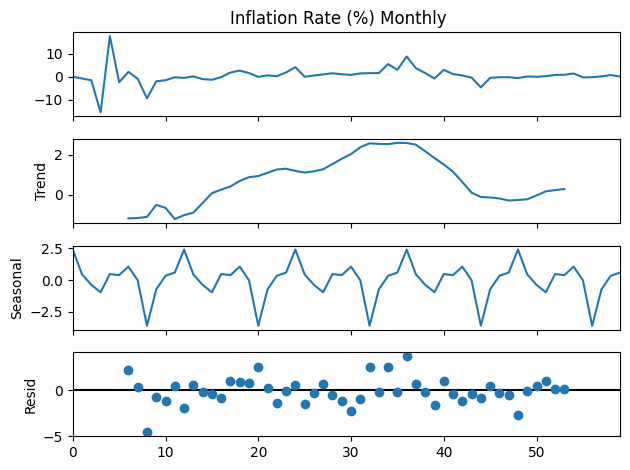

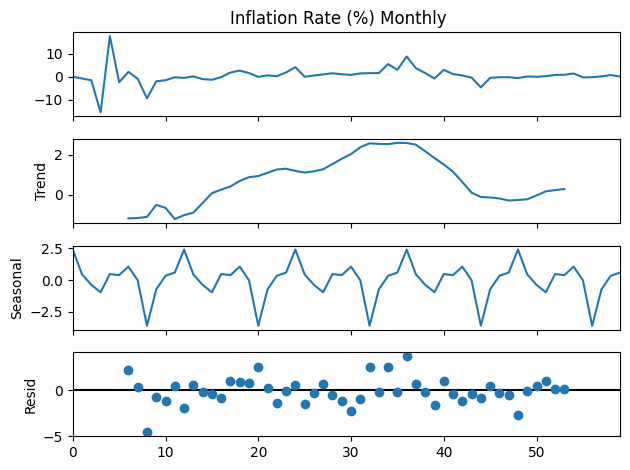

In [0]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df[df.columns[-3]],
    model='additive',
    period=12  # monthly data
)

result.plot()

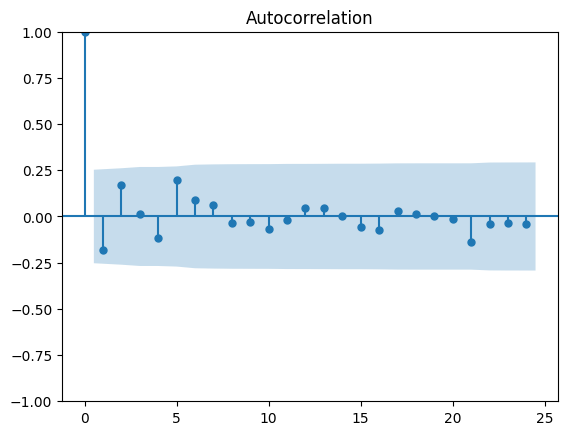

In [0]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df[df.columns[-3]], lags=24)
plt.show()

In [0]:
# !pip install prophet

In [0]:
df_prophet = df.reset_index()[['date', df.columns[-3]]]
df_prophet.columns = ['ds', 'y']
df_prophet.head(10)

,ds,y
0,2019-06-30,0.000000
1,2019-07-31,-0.761859
2,2019-08-31,-1.509782
3,2019-09-30,-15.361140
4,2019-10-31,17.533382
5,2019-11-30,-2.333053
6,2019-12-31,2.102968
7,2020-01-31,-0.859390
8,2020-02-29,-9.335626
9,2020-03-31,-1.959227


In [0]:
from prophet import Prophet

In [0]:
# train = df_prophet[:-12]
# test = df_prophet[-12:]

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

forecast = model.predict(future)

22:31:33 - cmdstanpy - INFO - Chain [1] start processing
22:31:33 - cmdstanpy - INFO - Chain [1] done processing
/local_disk0/.ephemeral_nfs/envs/pythonEnv-56eab0f1-f699-4ce8-817d-985b3535a646/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [0]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
67,2025-01-31,3.017345,-0.653471,6.860129
68,2025-02-28,-1.602219,-5.400681,2.312786
69,2025-03-31,0.977004,-2.492553,4.601312
70,2025-04-30,1.870261,-1.823160,5.612535
71,2025-05-31,1.902867,-1.620944,5.575324


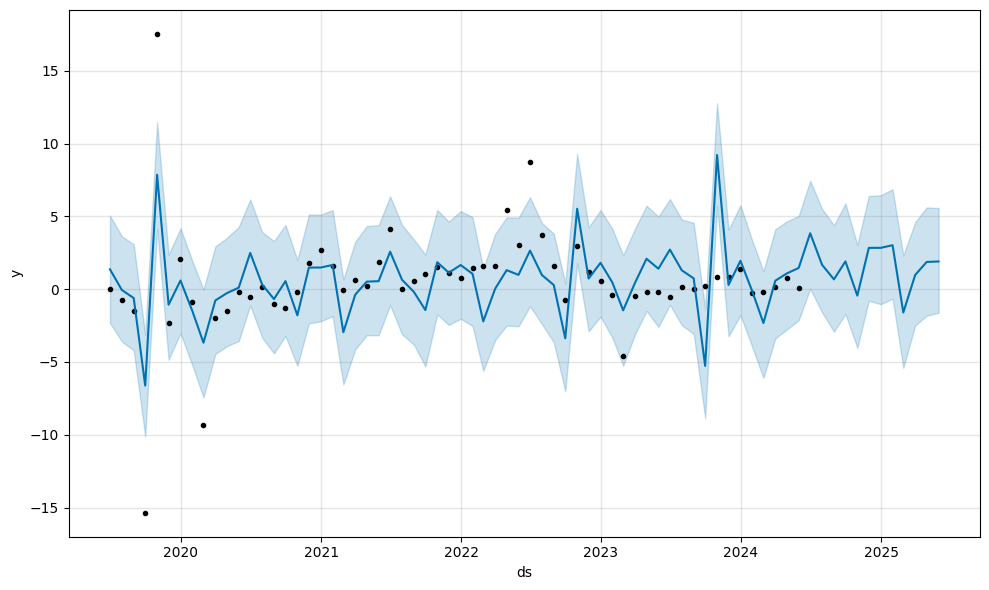

In [0]:
fig = model.plot(forecast)

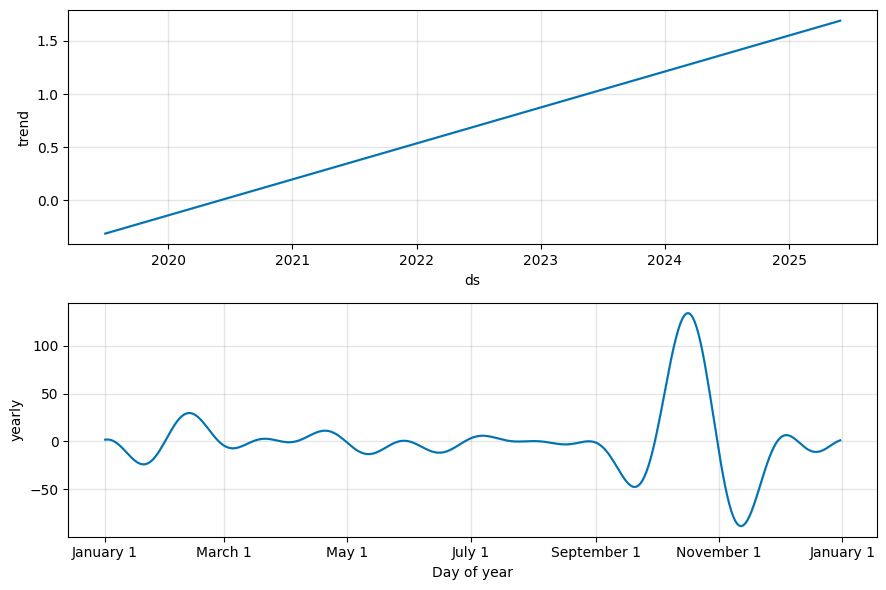

In [0]:
fig2 = model.plot_components(forecast)